In [28]:
import pandas as pd
import numpy as np
import matplotlib as nlp
import seaborn as sns

In [29]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nAttrition Count:")
print(df['Attrition'].value_counts())
print("\nMissing Values:", df.isnull().sum().sum())
df.head()

Shape: (1470, 35)

Attrition Count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Missing Values: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [30]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(df.columns.tolist())

df.columns = df.columns.str.strip().str.replace(' ','_')

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [31]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col, "-> constant column")
        
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], errors='ignore')

EmployeeCount -> constant column
Over18 -> constant column
StandardHours -> constant column


In [32]:
print(df.dtypes)
print(df.info())

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance              int64
YearsAtCompany               int64
YearsInCurrentRole  

In [33]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [34]:
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [35]:
df.to_csv('HR_Attrition_Cleaned.csv', index=False)

In [36]:
print(df.shape)
print(df.columns.tolist())
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)
print(len(categorical_cols))

(1470, 32)
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Flag']
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
8


In [37]:
print('Attrition_Flag' in df.columns)

True


# Overall Attrition Rate

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


# Attrition By Deparment

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition_Flag, dtype: float64


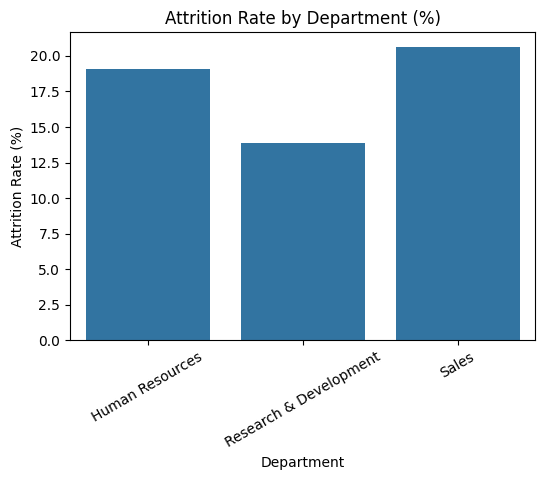

In [39]:
dept_attrition = df.groupby('Department')['Attrition_Flag'].mean() * 100
print(dept_attrition)

plt.figure(figsize=(6,4))
sns.barplot(x=dept_attrition.index, y=dept_attrition.values)
plt.title('Attrition Rate by Department (%)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=30)
plt.show()

# Attrition by OverTime

OverTime
No     10.436433
Yes    30.528846
Name: Attrition_Flag, dtype: float64


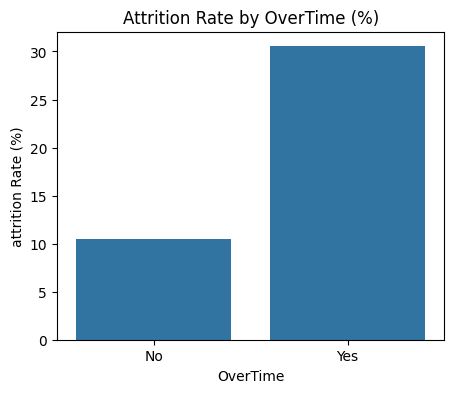

In [40]:
overtime_attrition = df.groupby('OverTime')['Attrition_Flag'].mean() * 100
print(overtime_attrition)

plt.figure(figsize=(5,4))
sns.barplot(x=overtime_attrition.index, y=overtime_attrition.values)
plt.title('Attrition Rate by OverTime (%)')
plt.ylabel('attrition Rate (%)')
plt.show()

# Attrition by JobRole

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition_Flag, dtype: float64


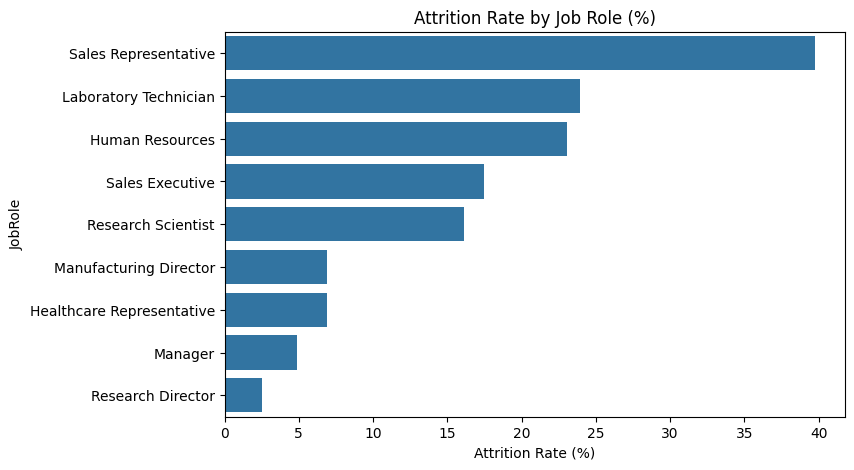

In [41]:
role_attrition = df.groupby('JobRole')['Attrition_Flag'].mean().sort_values(ascending=False) * 100
print(role_attrition)

plt.figure(figsize=(8,5))
sns.barplot(x=role_attrition.values, y=role_attrition.index)
plt.title('Attrition Rate by Job Role (%)')
plt.xlabel('Attrition Rate (%)')
plt.show()

# MonthlyIncome vs Attrition(boxplot)

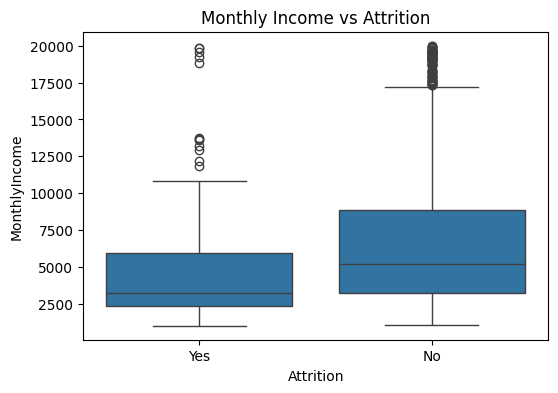

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.show()

# Age vs Attrition

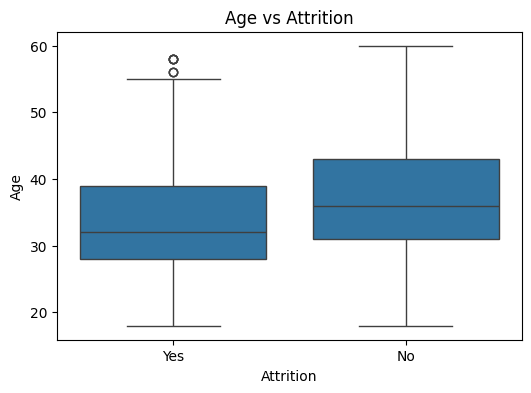

In [54]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title('Age vs Attrition')
plt.show()

# Correlation Heatmap (numerical columns)

<function matplotlib.pyplot.show(close=None, block=None)>

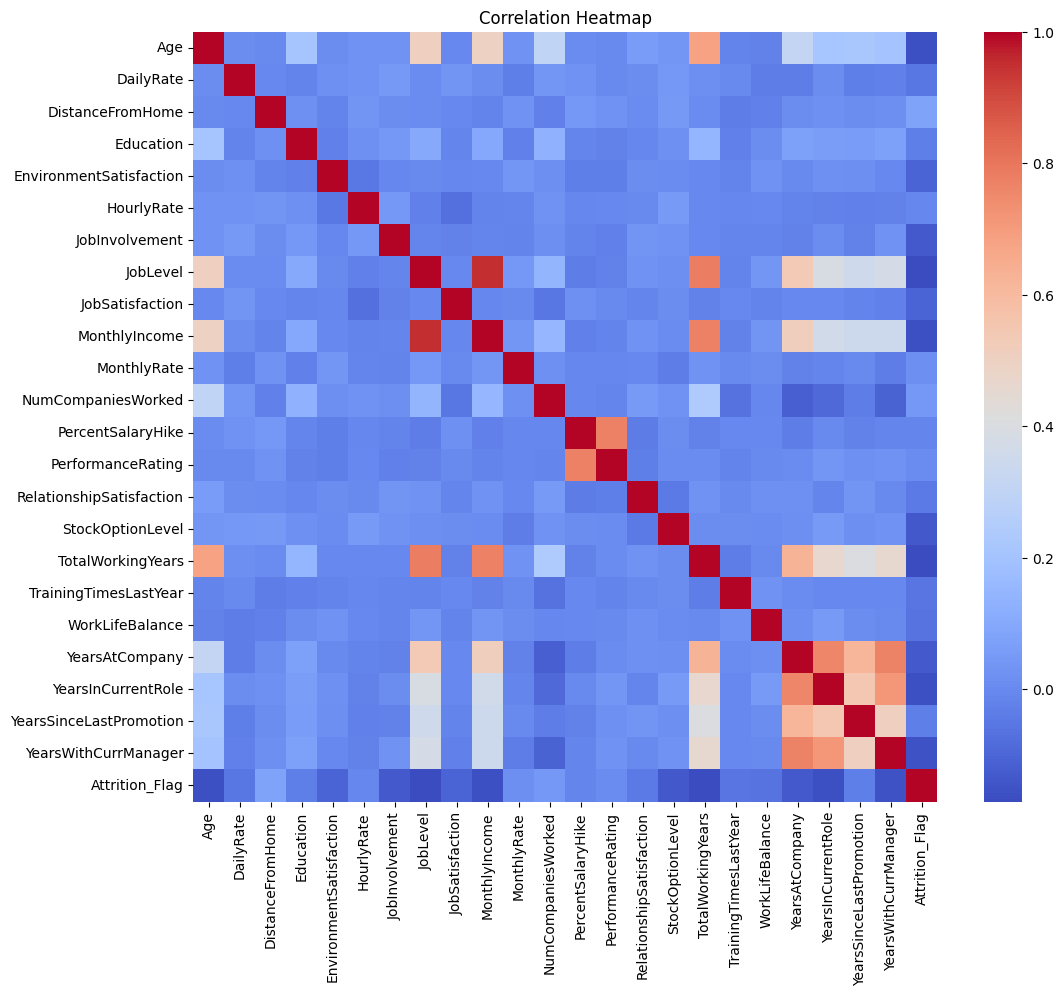

In [55]:
plt.figure(figsize=(12,10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show

# SQlite Integration

### Cleaned data loaded in SQLite database

In [46]:
import sqlite3

conn = sqlite3.connect('HR_Attrition.db')

df.to_sql('employees', conn, if_exists='replace', index=False)

print("Data successfully loaded into SQLite!")

Data successfully loaded into SQLite!


### Check the table for created properly or not

In [47]:
query = "SELECT * FROM employees LIMIT 5;"
result = pd.read_sql(query, conn)
print(result)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EnvironmentSatisfaction  \
0                 1          2  Life Sciences                        2   
1                 8          1  Life Sciences                        3   
2                 2          2          Other                        4   
3                 3          4  Life Sciences                        4   
4                 2          1        Medical                        1   

   Gender  ...  RelationshipSatisfaction  StockOptionLevel  TotalWorkingYears  \
0  Female  ...               

### Department-wise attrrition %

In [48]:
query1 = """
SELECT Department,
        ROUND(AVG(Attrition_Flag)*100, 2) AS Attrition_Rate
FROM employees
GROUP BY Department
ORDER BY Attrition_Rate DESC;
"""
print(pd.read_sql(query1, conn))

               Department  Attrition_Rate
0                   Sales           20.63
1         Human Resources           19.05
2  Research & Development           13.84


### OverTime vs Attrition %

In [49]:
query2 = """
SELECT OverTime,
       ROUND(AVG(Attrition_Flag)*100, 2) AS Attrition_Rate
FROM employees
GROUP BY OverTime;
"""
print(pd.read_sql(query2, conn))

  OverTime  Attrition_Rate
0       No           10.44
1      Yes           30.53


### Average tenure (YearsAtCompany) of employees who left vs stayed

In [50]:
query3 = """
SELECT Attrition,
       ROUND(AVG(YearsAtcompany), 2) AS Avg_Tenure,
       ROUND(AVG(MonthlyIncome), 2) AS Avg_Income
FROM employees
GROUP BY Attrition;
"""
print(pd.read_sql(query3, conn))

  Attrition  Avg_Tenure  Avg_Income
0        No        7.37     6832.74
1       Yes        5.13     4787.09


### Top 5 JobRoles by attrition rate

In [51]:
query4 = """
SELECT JobRole,
        ROUND(AVG(Attrition_Flag)*100, 2) AS Attrition_Rate,
        COUNT(*) AS Total_Employees
FROM employees
GROUP BY JobRole
ORDER BY Attrition_Rate DESC
LIMIT 5;
"""
print(pd.read_sql(query4, conn))

                 JobRole  Attrition_Rate  Total_Employees
0   Sales Representative           39.76               83
1  Laboratory Technician           23.94              259
2        Human Resources           23.08               52
3        Sales Executive           17.48              326
4     Research Scientist           16.10              292


### Attrition by Age group(bucketing)

In [56]:
query5 = """
SELECT
    CASE
        WHEN Age < 30 THEN 'Under 30'
        WHEN Age BETWEEN 30 AND 40 THEN '30-40'
        ELSE 'Above 40'
    END AS Age_Group,
    ROUND(AVG(Attrition_Flag)*100, 2) AS Attrition_Rate
FROM employees
GROUP BY Age_Group
ORDER BY Attrition_Rate Desc;
"""
print(pd.read_sql(query5, conn))

  Age_Group  Attrition_Rate
0  Under 30           27.91
1     30-40           13.84
2  Above 40           11.18


In [57]:
conn.close()